In [24]:
import scanpy as sc
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib import colors as mcolors
import warnings
warnings.filterwarnings("ignore")


def plot_spatial_compact_fast(
    ad,
    color="leiden_2",
    groupby="sample_id",
    spot_size=8,
    cols=3,
    height=8,
    legend_col_width=1.2,
    palette=None,            # dict {cat:"#hex"} or list
    rasterized=True,         # big speedup for vectors/PDFs
    invert_y=True,           # match Scanpy orientation
    dpi=120,                 # lower dpi → faster
):
    # ----- 0) Preconditions -----
    if "spatial" not in ad.obsm:
        raise ValueError("ad.obsm['spatial'] is required.")

    coords = np.asarray(ad.obsm["spatial"])[:, :2]
    cats = ad.obs[color].astype("category")
    cat_names = cats.cat.categories
    cat_codes = cats.cat.codes.to_numpy()  # -1 for NaN

    # ----- 1) Build shared palette (RGBA array) -----
    if isinstance(palette, dict):
        col_list = [palette[c] for c in cat_names]
    elif isinstance(palette, (list, tuple)):
        if len(palette) < len(cat_names):
            raise ValueError("Palette shorter than number of categories.")
        col_list = list(palette)[:len(cat_names)]
    elif f"{color}_colors" in ad.uns:
        col_list = list(ad.uns[f"{color}_colors"])
        if len(col_list) != len(cat_names):
            raise ValueError(f"{color}_colors length != categories.")
    else:
        base = getattr(getattr(__import__("scanpy").pl.palettes, "default_64", []), "__iter__", None)
        base = list(__import__("scanpy").pl.palettes.default_64
                    if hasattr(__import__("scanpy").pl.palettes, "default_64")
                    else __import__("scanpy").pl.palettes.default_102)
        reps = int(np.ceil(len(cat_names) / len(base)))
        col_list = (base * reps)[:len(cat_names)]

    # store for consistency elsewhere
    ad.uns[f"{color}_colors"] = col_list

    # convert to RGBA float array for fast indexing
    rgba = np.array([mcolors.to_rgba(c) for c in col_list], dtype=float)
    # map codes -> rgba; handle -1 (NaN) as transparent
    colors_arr = np.empty((cat_codes.size, 4), dtype=float)
    colors_arr[cat_codes >= 0] = rgba[cat_codes[cat_codes >= 0]]
    colors_arr[cat_codes < 0] = (0, 0, 0, 0)

    # ----- 2) Precompute group indices (no per-iteration masks) -----
    gvals = ad.obs[groupby].astype(str).to_numpy()
    uniq_groups, gcodes = np.unique(gvals, return_inverse=True)
    # list of index arrays per group
    group_indices = [np.flatnonzero(gcodes == gi) for gi in range(len(uniq_groups))]

    # ----- 3) Figure layout -----
    n = len(uniq_groups)
    rows = int(np.ceil(n / cols))
    panel_w = height * cols * 0.6 / rows
    fig_w = panel_w + legend_col_width

    plt.ioff()  # speed: disable interactive redraws
    fig = plt.figure(figsize=(fig_w, height), dpi=dpi, constrained_layout=False)
    gs = GridSpec(
        rows, cols + 1, figure=fig,
        width_ratios=[1]*cols + [legend_col_width / (fig_w - legend_col_width)],
        wspace=0.02, hspace=0.02
    )

    # ----- 4) Panels (fast scatter) -----
    for i, sid in enumerate(uniq_groups):
        r, c = divmod(i, cols)
        ax = fig.add_subplot(gs[r, c])

        idx = group_indices[i]
        if idx.size:
            xy = coords[idx]
            # note: turn off edgecolor & use rasterized for speed
            sca = ax.scatter(
                xy[:, 0], xy[:, 1],
                c=colors_arr[idx],
                s=spot_size,
                marker='o',
                linewidths=0,
                rasterized=rasterized
            )
        ax.set_title(str(sid), fontsize=9, pad=2)
        ax.set_aspect("equal")
        if invert_y:
            ax.invert_yaxis()
        ax.set_axis_off()

    # blank unused
    for j in range(n, rows * cols):
        r, c = divmod(j, cols)
        fig.add_subplot(gs[r, c]).axis("off")

    # ----- 5) Legend (single, shared) -----
    ax_leg = fig.add_subplot(gs[:, -1])
    ax_leg.axis("off")
    handles = [
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor=col_list[k], markersize=7, label=str(cat))
        for k, cat in enumerate(cat_names)
    ]
    ax_leg.legend(handles=handles, title=color, frameon=False, loc="center left")

    fig.subplots_adjust(left=0.01, right=0.98, top=0.98, bottom=0.02, wspace=0.02, hspace=0.02)
    plt.ion()  # ✅ correct
    plt.show()

import os
import numpy as np
import pandas as pd
from anndata import AnnData
from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats
from statsmodels.stats.multitest import multipletests

import pandas as pd
import numpy as np
import scipy.sparse as sp
from collections import defaultdict

def _to_dense(X):
    return X.toarray() if sp.issparse(X) else np.asarray(X)

def pseudobulk_by(
    adata,
    groupby=["cell_class", "region", "age", "condition"],
    layer=None,
    min_cells=30,
):
    """
    Create pseudobulk counts per unique combination of the groupby factors.

    Returns:
        pb_dict[cell_class][(region, age)] = (counts_df, meta_df)
        - counts_df: genes x pseudobulk-samples
        - meta_df:   rows = pseudobulk-samples (index = pb_key), cols = groupby fields
    """
    X = _to_dense(adata.layers[layer] if layer else adata.X)
    obs = adata.obs.copy()
    genes = adata.var_names

    # Build a stable pseudobulk key
    obs["pb_key"] = obs[groupby].astype(str).agg("__".join, axis=1)

    # Sum counts per pseudobulk key
    summed = (
        pd.DataFrame(X, index=obs["pb_key"], columns=genes)
        .groupby(level=0)
        .sum()
    )

    # Group metadata (indexed by pb_key already)
    meta = obs[groupby + ["pb_key"]].drop_duplicates("pb_key").set_index("pb_key")

    pb = defaultdict(dict)
    for key, row in meta.iterrows():
        cell_class = row["cell_class"]
        reg = row["region"]
        age = str(row["age"])

        # one pseudobulk column for this (cell_class, region, age, condition)
        counts_col = summed.loc[[key]].T
        counts_col.columns = [key]

        # pull the corresponding one-row metadata frame (indexed by pb_key)
        meta_row = meta.loc[[key]]

        if (reg, age) in pb[cell_class]:
            counts_df_all, meta_df = pb[cell_class][(reg, age)]
            counts_df_all = pd.concat([counts_df_all, counts_col], axis=1)
            meta_df = pd.concat([meta_df, meta_row], axis=0)
        else:
            counts_df_all = counts_col
            meta_df = meta_row

        pb[cell_class][(reg, age)] = (counts_df_all, meta_df)

    # Optional: drop group slots with too few cells total
    # (counts of cells in obs, not number of pseudobulk samples)
    to_prune = []
    for cl in list(pb.keys()):
        for (reg, age), (counts_df, meta_df) in list(pb[cl].items()):
            n_cells = (
                (obs["cell_class"] == cl)
                & (obs["region"] == reg)
                & (obs["age"].astype(str) == age)
            ).sum()
            if n_cells < min_cells:
                to_prune.append((cl, (reg, age)))
    for cl, key in to_prune:
        del pb[cl][key]

    return pb

# ---------- helpers from earlier ----------
def _align(counts_df, meta_df):
    if not counts_df.columns.equals(meta_df.index):
        common = counts_df.columns.intersection(meta_df.index)
        if len(common)==0:
            raise ValueError("No overlapping sample IDs")
        counts_df = counts_df.loc[:, common]
        meta_df   = meta_df.loc[common]
    return counts_df, meta_df

def _to_anndata(counts_df, meta_df):
    X = counts_df.T.astype(np.int64)
    ad = AnnData(X=X.values)
    ad.obs_names = X.index.astype(str)
    ad.var_names = counts_df.index.astype(str)
    ad.obs = meta_df.copy()
    return ad

def _prep_condition(mdf, condition_col="condition", ref_condition="control"):
    mdf = mdf.copy()
    mdf[condition_col] = mdf[condition_col].astype(str).str.strip()
    uniq = list(pd.unique(mdf[condition_col]))
    if ref_condition not in uniq:
        m = [u for u in uniq if u.lower()==ref_condition.lower()]
        if not m:
            raise ValueError(f"Ref '{ref_condition}' not present. Found: {uniq}")
        ref_condition = m[0]
    mdf[condition_col] = pd.Categorical(mdf[condition_col],
                                        categories=[ref_condition]+[u for u in uniq if u!=ref_condition],
                                        ordered=True)
    return mdf, ref_condition

def simple_effect_at_subset(counts_df, meta_df, mask, condition_col="condition",
                            ref_condition="control", n_cpus=8, label=""):
    """Generic: run mtDSB vs control inside boolean `mask` on meta_df."""
    counts_df, meta_df = _align(counts_df, meta_df)
    if mask.sum() < 2:
        raise ValueError(f"Not enough samples for subset: {label}")
    cdf = counts_df.loc[:, mask]
    mdf = meta_df.loc[mask].copy()
    mdf, ref_condition = _prep_condition(mdf, condition_col=condition_col, ref_condition=ref_condition)

    # detect case level
    cats = mdf[condition_col].cat.categories.tolist()
    case = [c for c in cats if c != ref_condition][0] if len(cats)>1 else None
    if case is None:
        raise ValueError(f"No case level in subset: {label}")

    ad = _to_anndata(cdf, mdf)
    dds = DeseqDataSet(adata=ad, design_factors=[condition_col],
                       refit_cooks=True, inference=DefaultInference(n_cpus=n_cpus))
    dds.deseq2()
    st = DeseqStats(dds, contrast=[condition_col, case, ref_condition], inference=DefaultInference(n_cpus=n_cpus))
    st.summary()
    res = st.results_df.copy()
    # standardize column names
    res = res.rename(columns={
        "log2FoldChange": f"log2FC_{case}_vs_{ref_condition}",
        "lfcSE":          f"lfcSE_{case}_vs_{ref_condition}",
        "pvalue":         f"pvalue_{case}_vs_{ref_condition}",
        "padj":           f"padj_{case}_vs_{ref_condition}",
    })
    res.attrs = {"subset_label": label, "case": case, "ref": ref_condition}
    return res

def combine_delta(res_A, res_B, lfc_prefix="log2FC_", se_prefix="lfcSE_",
                  p_colname="p_delta", q_colname="q_delta"):
    """Generic Δ (B − A) with z-test using SEs; works for ages or regions."""
    lfc_A = [c for c in res_A.columns if c.startswith(lfc_prefix)][0]
    se_A  = [c for c in res_A.columns if c.startswith(se_prefix)][0]
    lfc_B = [c for c in res_B.columns if c.startswith(lfc_prefix)][0]
    se_B  = [c for c in res_B.columns if c.startswith(se_prefix)][0]
    df = pd.DataFrame(index=res_A.index.union(res_B.index))
    df[lfc_A] = res_A[lfc_A]; df[se_A] = res_A[se_A]
    df[lfc_B] = res_B[lfc_B]; df[se_B] = res_B[se_B]
    df = df.dropna(subset=[lfc_A, se_A, lfc_B, se_B]).copy()
    df["delta_log2FC"] = df[lfc_B] - df[lfc_A]
    df["se_delta"] = np.sqrt(np.square(df[se_A]) + np.square(df[se_B]))
    df["se_delta"] = df["se_delta"].replace(0, np.nan)
    df = df.dropna(subset=["se_delta"])
    df["z"] = df["delta_log2FC"] / df["se_delta"]
    from scipy.stats import norm
    df[p_colname] = 2*(1 - norm.cdf(np.abs(df["z"])))
    df[q_colname] = multipletests(df[p_colname], method="fdr_bh")[1]
    return df

# ---------- NEW: region-aware analysis ----------
def run_by_region(pb,                      # dict: ct -> (counts_df, meta_df)
                  condition_col="condition",
                  age_col="age",
                  region_col="region",     # <- your anatomical label column
                  min_per_group=2,         # min samples per condition in a subset
                  n_cpus=8):
    """
    For each cell type & region:
      - per-age simple effect: mtDSB vs control within (region, age)
      - region impact score per age (intensity of effect)
      - region-vs-region ΔLFC at same age (interaction proxy)
    Returns nested dict: results[ct][region] -> {...}
    """
    results = {}
    for ct, (counts_df, meta_df) in pb.items():
        counts_df, meta_df = _align(counts_df, meta_df)
        # normalize fields
        md = meta_df.copy()
        md[age_col] = md[age_col].astype(str).str.strip()
        md[region_col] = md[region_col].astype(str).str.strip()
        md[condition_col] = md[condition_col].astype(str).str.strip()

        regions = list(pd.unique(md[region_col]))
        ages    = list(pd.unique(md[age_col]))
        ct_out = {}
        for reg in regions:
            reg_out = {"simple_effects": {}, "impact": {}, "age_list": ages, "region": reg}
            for a in ages:
                mask = (md[region_col]==reg) & (md[age_col]==a)
                # require at least min_per_group per condition
                if mask.sum() >= 2 and all((md.loc[mask, condition_col].value_counts() >= min_per_group).reindex(md[condition_col].unique(), fill_value=0)[:2]):
                    try:
                        res = simple_effect_at_subset(
                            counts_df, md, mask,
                            condition_col=condition_col, ref_condition="control",
                            n_cpus=n_cpus, label=f"{reg}@{a}"
                        )
                        reg_out["simple_effects"][a] = res
                        # impact score: count of sig genes & sum -log10(FDR) among sig
                        lfc_col = [c for c in res.columns if c.startswith("log2FC_")][0]
                        padj_col = [c for c in res.columns if c.startswith("padj_")][0]
                        sig = (res[padj_col] < 0.05) & (res[lfc_col].abs() >= 1.0)
                        reg_out["impact"][a] = {
                            "n_sig": int(sig.sum()),
                            "sum_neglog10q": float((-np.log10(res.loc[sig, padj_col].clip(lower=1e-300))).sum())
                        }
                    except Exception as e:
                        reg_out["simple_effects"][a] = None
                        reg_out["impact"][a] = {"n_sig": 0, "sum_neglog10q": 0.0}
                else:
                    reg_out["simple_effects"][a] = None
                    reg_out["impact"][a] = {"n_sig": 0, "sum_neglog10q": 0.0}
            ct_out[reg] = reg_out

        # region-vs-region ΔLFC at same age (interaction proxy)
        # For each age, compare each pair of regions’ mtDSB effects
        for regA, regB in [(r1, r2) for i, r1 in enumerate(regions) for r2 in regions[i+1:]]:
            for a in ages:
                resA = ct_out[regA]["simple_effects"].get(a)
                resB = ct_out[regB]["simple_effects"].get(a)
                if resA is None or resB is None:
                    continue
                dtab = combine_delta(resA, resB, p_colname="p_delta_region", q_colname="q_delta_region")
                if "deltas_region" not in ct_out[regA]:
                    ct_out[regA]["deltas_region"] = {}
                if "deltas_region" not in ct_out[regB]:
                    ct_out[regB]["deltas_region"] = {}
                ct_out[regA]["deltas_region"][(a, regB)] = dtab  # Δ = regB − regA at age a
                # also store the opposite direction (flip sign)
                dtab_flip = dtab.copy()
                dtab_flip["delta_log2FC"] = -dtab_flip["delta_log2FC"]
                dtab_flip["z"] = -dtab_flip["z"]
                ct_out[regB]["deltas_region"][(a, regA)] = dtab_flip

        results[ct] = ct_out
    return results

# ---------- ranking regions by "affectedness" ----------
def summarize_region_impact(results_by_region, ct, metric="sum_neglog10q", age=None):
    """
    Build a ranking table of regions by impact metric.
    metric: "n_sig" or "sum_neglog10q"
    age: specific age or None to aggregate across ages (sum).
    """
    rows = []
    for reg, d in results_by_region[ct].items():
        imp = d.get("impact", {})
        if age is None:
            vals = [imp[a][metric] for a in imp.keys()]
            score = np.nansum(vals)
        else:
            score = imp.get(str(age), {}).get(metric, 0.0) if str(age) in imp else 0.0
        rows.append({"region": reg, "score": score})
    out = pd.DataFrame(rows).sort_values("score", ascending=False).reset_index(drop=True)
    return out

from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats
import numpy as np
import pandas as pd
from statsmodels.stats.multitest import multipletests
from scipy.stats import norm

def _align(counts_df, meta_df):
    common = counts_df.columns.intersection(meta_df.index)
    return counts_df.loc[:, common], meta_df.loc[common]

def simple_effect_at_subset(counts_df, meta_df, mask, condition_col="condition",
                            ref_condition="control", n_cpus=8, label=""):
    counts_df, meta_df = _align(counts_df, meta_df)
    if mask.sum() < 2:
        raise ValueError(f"Not enough samples for subset {label}")
    cdf = counts_df.loc[:, mask]
    mdf = meta_df.loc[mask].copy()
    mdf[condition_col] = pd.Categorical(
        mdf[condition_col].astype(str),
        categories=[ref_condition] + [x for x in mdf[condition_col].unique() if x != ref_condition],
        ordered=True
    )
    adata = cdf.T
    inference = DefaultInference(n_cpus=n_cpus)
    dds = DeseqDataSet(adata=adata, clinical=mdf, design_factors=[condition_col],
                       refit_cooks=True, inference=inference)
    dds.deseq2()
    st = DeseqStats(dds, contrast=[condition_col, "mtDSB", ref_condition], inference=inference)
    st.summary()
    return st.results_df.copy()

def run_by_region(pb_class, condition_col="condition", age_col="age",
                  region_col="region", min_per_group=2, n_cpus=8):
    results = {}
    for cl, (counts_df, meta_df) in pb_class.items():
        md = meta_df.copy()
        md[age_col] = md[age_col].astype(str)
        md[region_col] = md[region_col].astype(str)
        md[condition_col] = md[condition_col].astype(str)
        ages = md[age_col].unique()
        regions = md[region_col].unique()

        cl_results = {}
        for reg in regions:
            reg_out = {"simple_effects": {}, "impact": {}}
            for age in ages:
                mask = (md[region_col]==reg) & (md[age_col]==age)
                if mask.sum() < 2: continue
                try:
                    res = simple_effect_at_subset(
                        counts_df, md, mask,
                        condition_col=condition_col,
                        ref_condition="control",
                        n_cpus=n_cpus,
                        label=f"{cl}_{reg}_{age}"
                    )
                    lfc_col = [c for c in res.columns if "log2FoldChange" in c][0]
                    padj_col = [c for c in res.columns if "padj" in c][0]
                    sig = (res[padj_col] < 0.05) & (res[lfc_col].abs() > 1)
                    reg_out["simple_effects"][age] = res
                    reg_out["impact"][age] = {
                        "n_sig": int(sig.sum()),
                        "sum_neglog10q": float((-np.log10(res.loc[sig, padj_col].clip(lower=1e-300))).sum())
                    }
                except Exception:
                    pass
            cl_results[reg] = reg_out
        results[cl] = cl_results
    return results

def summarize_region_impact(results_by_region, cell_class, metric="sum_neglog10q", age=None):
    rows = []
    for reg, d in results_by_region[cell_class].items():
        imp = d["impact"]
        if not imp: continue
        if age is None:
            vals = [v[metric] for v in imp.values()]
            score = np.nansum(vals)
        else:
            score = imp.get(str(age), {}).get(metric, 0.0)
        rows.append({"region": reg, "score": score})
    out = pd.DataFrame(rows).sort_values("score", ascending=False).reset_index(drop=True)
    return out
import numpy as np
import pandas as pd
from anndata import AnnData
from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats

def _as_anndata(counts_df, meta_df):
    ad = AnnData(counts_df.T)
    ad.obs = meta_df.copy()
    ad.var_names = counts_df.index
    ad.obs_names = counts_df.columns
    return ad

def run_by_region(
    pb_class,
    condition_col="condition",
    age_col="age",
    region_col="region",
    ref_condition="control",
    min_per_condition=2,
    n_cpus=8,
    verbose=True
):
    results = {}
    for cl, (counts_df, meta_df) in pb_class.items():
        counts_df, meta_df = counts_df.copy(), meta_df.copy()
        md = meta_df.copy()
        md[age_col] = md[age_col].astype(str)
        md[region_col] = md[region_col].astype(str)
        md[condition_col] = md[condition_col].astype(str)
        ages = sorted(md[age_col].unique(), key=lambda x: (len(x), x))
        regions = sorted(md[region_col].unique())
        inference = DefaultInference(n_cpus=n_cpus)

        cl_out = {}
        for reg in regions:
            reg_out = {"simple_effects": {}, "impact": {}}
            for age in ages:
                mask = (md[region_col]==reg) & (md[age_col]==age)
                sub = md.loc[mask]
                if sub.empty: 
                    continue
                vc = sub[condition_col].value_counts()
                if len(vc) < 2 or any(vc < min_per_condition):
                    if verbose: print(f"[{cl}] skip {reg}@{age} (counts {vc.to_dict()})")
                    continue
                case = [x for x in vc.index if x != ref_condition][0]
                if verbose: print(f"[{cl}] running {reg}@{age} ({vc.to_dict()})")

                ad = _as_anndata(counts_df.loc[:, sub.index], sub)
                dds = DeseqDataSet(
                    adata=ad,
                    design_factors=[condition_col],
                    refit_cooks=True,
                    inference=inference
                )
                dds.deseq2()
                st = DeseqStats(dds, contrast=[condition_col, case, ref_condition], inference=inference)
                st.summary()
                res = st.results_df.copy()

                lfc_col = "log2FoldChange"
                padj_col = "padj"
                sig = (res[padj_col] < 0.05) & (res[lfc_col].abs() >= 1.0)
                reg_out["simple_effects"][age] = res
                reg_out["impact"][age] = {
                    "n_sig": int(sig.sum()),
                    "sum_neglog10q": float((-np.log10(res.loc[sig, padj_col].clip(lower=1e-300))).sum())
                }

            cl_out[reg] = reg_out
        results[cl] = cl_out
    return results
import numpy as np
import matplotlib.pyplot as plt

def volcano_clean(
    res_df,
    lfc_col="log2FoldChange",
    padj_col="padj",
    title="mtDSB vs control",
    lfc_thr=1.0,
    q=0.05,
    label_top_fdr=10,           # top genes by FDR to label
    label_top_abs_lfc=10,       # top by |LFC|
    max_labels=20,              # absolute label cap
    highlight_genes=None,       # list of genes to force label
    figsize=(9,7),
    fontsize=13
):
    """Pretty volcano plot for DESeq2 / PyDESeq2 results."""

    df = res_df.copy().replace([np.inf, -np.inf], np.nan).dropna(subset=[lfc_col, padj_col])
    df["neglog10q"] = -np.log10(df[padj_col].clip(lower=1e-300))
    sig = (df[padj_col] < q) & (df[lfc_col].abs() >= lfc_thr)

    # pick label set
    idx_fdr = df.sort_values(padj_col).head(label_top_fdr).index
    idx_lfc = df.reindex(df[lfc_col].abs().sort_values(ascending=False).head(label_top_abs_lfc).index).index
    pick = set(idx_fdr).union(set(idx_lfc))
    if highlight_genes:
        pick.update(set(df.index.intersection(highlight_genes)))
    if len(pick) > max_labels:
        pick = set(df.loc[list(pick)].sort_values("neglog10q", ascending=False).head(max_labels).index)

    # figure
    plt.figure(figsize=figsize, dpi=150)
    plt.scatter(df[lfc_col], df["neglog10q"], s=16, alpha=0.35, color="lightgrey", label="not sig")
    up = df[sig & (df[lfc_col] > 0)]
    dn = df[sig & (df[lfc_col] < 0)]
    plt.scatter(up[lfc_col], up["neglog10q"], s=28, color="#d73027", label="Up (sig)")
    plt.scatter(dn[lfc_col], dn["neglog10q"], s=28, color="#4575b4", label="Down (sig)")

    # thresholds
    plt.axvline(+lfc_thr, ls="--", color="k", lw=1)
    plt.axvline(-lfc_thr, ls="--", color="k", lw=1)
    plt.axhline(-np.log10(q), ls="--", color="k", lw=1)

    plt.xlabel("log₂ fold change (mtDSB vs control)", fontsize=fontsize)
    plt.ylabel("-log₁₀(FDR)", fontsize=fontsize)
    plt.title(title, fontsize=fontsize+2, pad=10)

    # label genes
    texts = []
    try:
        from adjustText import adjust_text
        for g in pick:
            x, y = df.at[g, lfc_col], df.at[g, "neglog10q"]
            t = plt.text(x, y, g, fontsize=fontsize-3, va="bottom", ha="center")
            texts.append(t)
            plt.scatter([x],[y], s=40, edgecolor="black", linewidth=0.6, zorder=4)
        adjust_text(
            texts,
            only_move={'points':'y', 'text':'xy'},
            expand_points=(1.2, 1.4),
            expand_text=(1.1, 1.2),
            arrowprops=dict(arrowstyle="-", lw=0.8, color="0.25"),
        )
    except ImportError:
        for g in pick:
            x, y = df.at[g, lfc_col], df.at[g, "neglog10q"]
            plt.annotate(
                g, xy=(x, y), xytext=(x+0.2*np.sign(x), y+0.3),
                fontsize=fontsize-3,
                arrowprops=dict(arrowstyle="-", lw=0.8, color="0.25"),
                ha="center", va="bottom"
            )
            plt.scatter([x],[y], s=40, edgecolor="black", linewidth=0.6, zorder=4)

    plt.legend(frameon=False, fontsize=fontsize-3)
    plt.tight_layout()
    plt.show()


In [13]:
adata = sc.read_h5ad('/date/gcb/gcb_CML/oligo-mtDSB/results/rbd_runs/--data-base/rbd_annotated_monod_annotated.h5ad')

In [25]:
adata.obs.RBD_compartment_simplified.unique()

['Cortex', 'Unknown', 'Meningeal border/glia limitans', 'Fiber tracts', 'Vasculature', ..., 'Hippocampus', 'Thalamus', 'Olfactory areas', 'Hypothalamus', 'Pallidum']
Length: 12
Categories (12, object): ['Cortex', 'Fiber tracts', 'Hippocampus', 'Hypothalamus', ..., 'Thalamus', 'Unknown', 'Vasculature', 'Ventricular system']

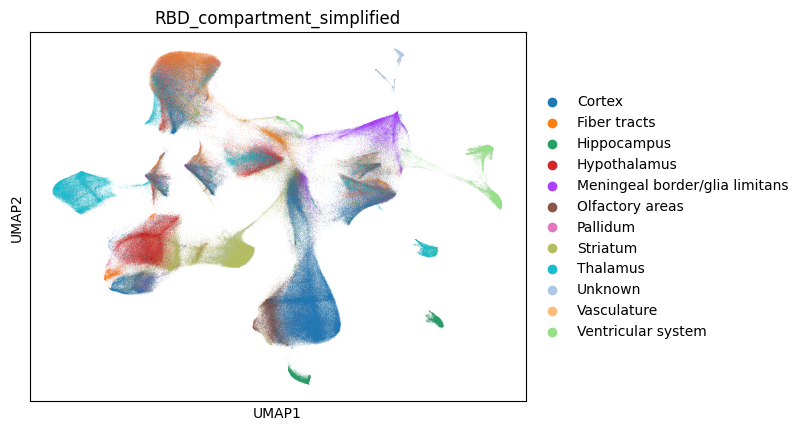

In [17]:
sc.pl.umap(adata, color = 'RBD_compartment_simplified')

Plotting RBD_compartment_simplified …


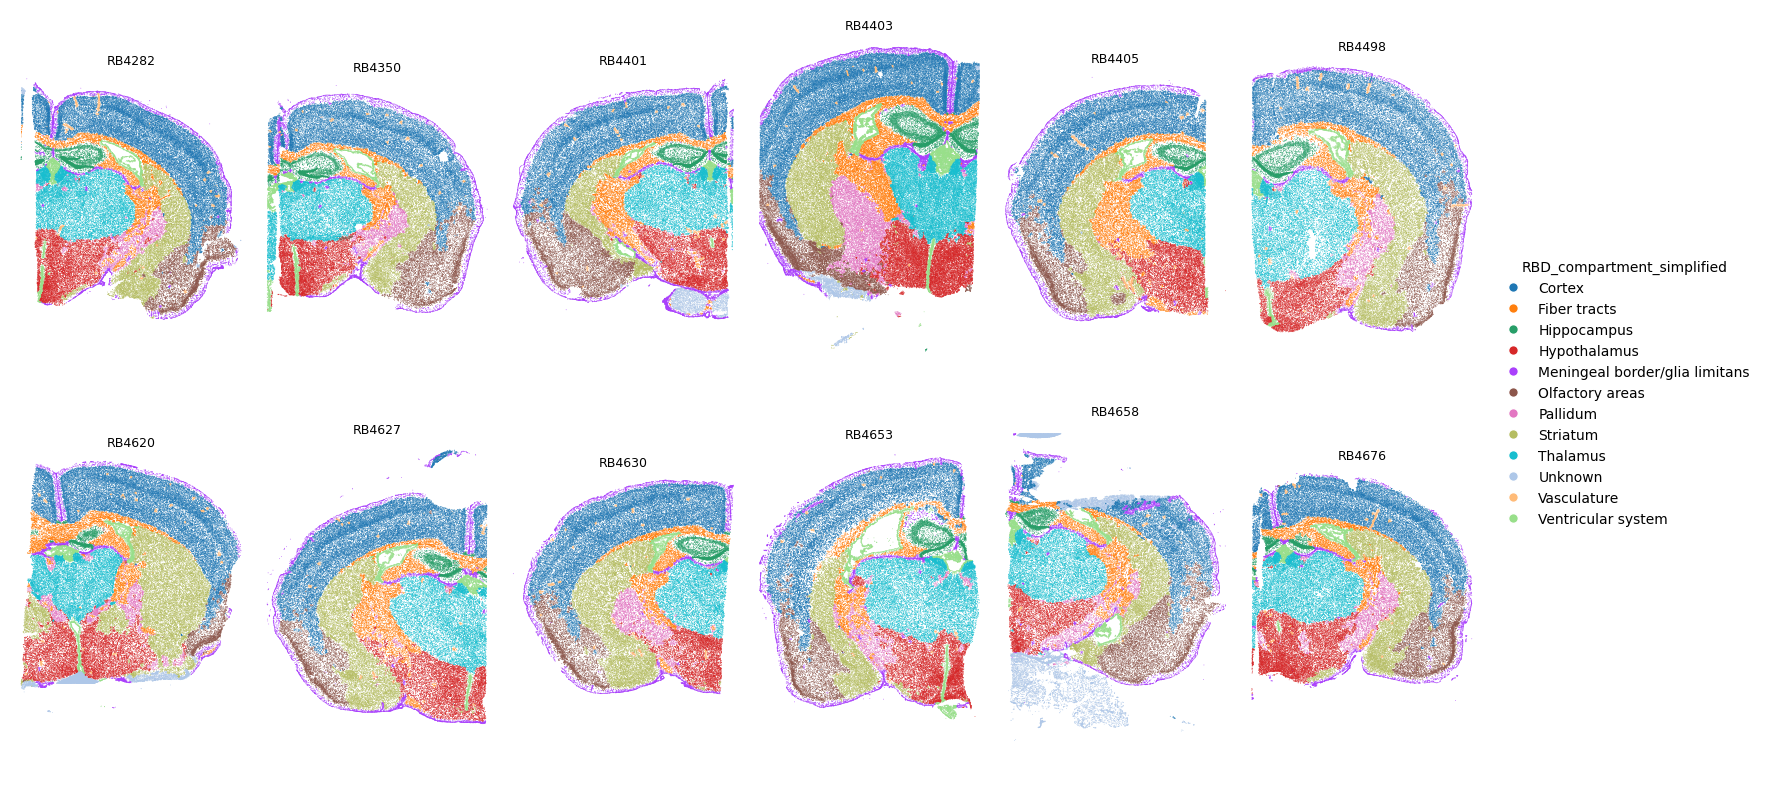

In [22]:
for domain in ['RBD_compartment_simplified']:
    if domain in adata.obs.columns:
        print(f"Plotting {domain} …")
        plot_spatial_compact_fast(
            adata,
            color=domain,
            groupby="sample_id",
            spot_size=0.3,
            cols=6,
            height=8,
            legend_col_width=1.0,
            rasterized=True,   # big speedup for large data
            dpi=100             # lower = faster preview
        )
    else:
        print(f"Skipping {domain} — not in adata.obs")

In [27]:
pb = pseudobulk_by(
    adata,
    groupby=["cell_class", "RBD_compartment_simplified", "age", "condition", "sample_id"],  # 👈 add sample_id
    layer="counts" if "counts" in adata.layers else None,
    min_cells=30,
)

# Inspect one example
cell_type = "Mature oligodendrocytes"
region_age = list(pb[cell_type].keys())[0]
counts_df, meta_df = pb[cell_type][region_age]

print(region_age)
print("Counts shape:", counts_df.shape)
print(meta_df.head())

MemoryError: Unable to allocate 18.6 GiB for an array with shape (980474, 5101) and data type float32